# CIFAR-10 / ResNet18 — headline + parameter-fraction

Sven vs baselines on ResNet18 (Gram makes this tractable). Headline convergence, and the Fig-5 parameter-fraction sweep (accuracy vs fraction of parameters updated).

> Loads the fresh Gram-backend results. Robust to partial data (plots whatever has finished).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import (add_derived, best_per_method, seed_mean_best, config_runs, seed_band,
                              errorbar_seeds, fmt_pm, epochs_to_target_table, valid, loss_curve, method_order,
                              n_params_of)
from style import DATASET_TITLES, metric_label
from style import clipped_yerr
from pathlib import Path
set_style()
PLOT_DIR = Path('plots_v2/cifar'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
from style import method_color
def sven_color(m): return method_color(m)   # global optimizer colours (style.METHOD_COLORS)
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
head={DATASET_TITLES['cifar_labelreg']:'cifar10_resnet_scan_labelRegression', DATASET_TITLES['cifar_ce']:'cifar10_resnet_ce_scan'}
pf={'label-reg (paper)':'cifar10_resnet_paramFrac_scan_labelReg',
    'label-reg (rebuttal 3-seed)':'rebuttal_fig5_cifar_paramfrac_scan'}
H={}; PF={}
for t,n in head.items():
    try: H[t]=add_derived(load_results(n))
    except FileNotFoundError: print('missing',n)
for t,n in pf.items():
    try: PF[t]=add_derived(load_results(n))
    except FileNotFoundError: print('missing',n)

Loaded 290 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
Loaded 290 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
missing cifar10_resnet_paramFrac_scan_labelReg
missing rebuttal_fig5_cifar_paramfrac_scan


### Headline: best per method

In [3]:
for t,df in H.items():
    b=best_per_method(df, by='final_val_loss').sort_values('final_val_loss')
    print(f'== {t} ==  (best config per optimizer by seed-mean val loss; mean ± std over seeds)')
    for _,r in b.iterrows():
        acc=f"  acc={fmt_pm(r,'final_val_acc','.3f')}" if r.final_val_acc==r.final_val_acc else ''
        print(f"  {r.method:10s} val={fmt_pm(r,'final_val_loss','.4f')}{acc}  seeds={r.n_seeds} diverged={r.n_diverged}")

== CIFAR-10 (label reg.) ==  (best config per optimizer by seed-mean val loss; mean ± std over seeds)
  Adam       val=0.3986 ± 0.0119  acc=0.739 ± 0.005  seeds=5 diverged=0
  Sven       val=0.4142 ± 0.0157  acc=0.739 ± 0.002  seeds=5 diverged=0
  RMSprop    val=0.4157 ± 0.0123  acc=0.734 ± 0.010  seeds=5 diverged=0
  PolyakSGD  val=0.4459 ± 0.0100  acc=0.712 ± 0.009  seeds=5 diverged=0
  LBFGS      val=0.6991 ± 0.0139  acc=0.550 ± 0.007  seeds=5 diverged=0
  SGD        val=0.7243 ± 0.0095  acc=0.463 ± 0.006  seeds=5 diverged=0
== CIFAR-10 (CE) ==  (best config per optimizer by seed-mean val loss; mean ± std over seeds)
  RMSprop    val=1.1983 ± 0.0841  acc=0.632 ± 0.029  seeds=5 diverged=0
  Adam       val=1.2156 ± 0.0239  acc=0.753 ± 0.004  seeds=5 diverged=0
  LBFGS      val=1.3201 ± 0.0198  acc=0.536 ± 0.008  seeds=5 diverged=0
  SGD        val=1.3391 ± 0.0208  acc=0.539 ± 0.007  seeds=5 diverged=0
  Sven       val=1.4148 ± 0.0170  acc=0.531 ± 0.007  seeds=5 diverged=0
  PolyakSGD 

### Fig-5: accuracy vs parameter fraction (Sven)

/var/folders/l6/xpd37x8x5md3j2v6qz37ptrc0000gn/T/ipykernel_18387/3909293962.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_xlabel('Parameter fraction $f$'); ax.set_ylabel(metric_label(q)); ax.legend(fontsize=8)


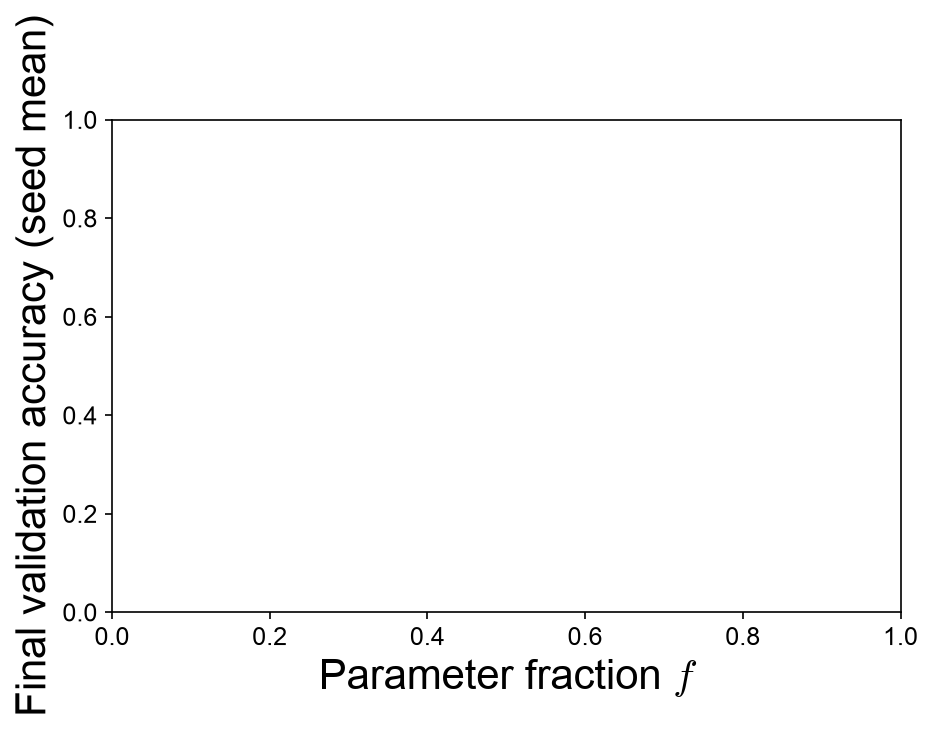

In [4]:
fig,ax=plt.subplots(figsize=(6.5,4.4))
q = 'final_val_acc'   # what the y axis shows (falls back to loss below if no accuracy)
for t,df in PF.items():
    if 'param_fraction' not in df or df.empty: continue
    # best config per param_fraction by SEED-MEAN val loss; error bars = seed spread
    g=seed_mean_best(df, 'param_fraction')
    q = 'final_val_acc' if g['final_val_acc'].notna().any() else 'final_val_loss'
    errorbar_seeds(ax, g, 'param_fraction', q, label=t)
ax.set_xlabel('Parameter fraction $f$'); ax.set_ylabel(metric_label(q)); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOT_DIR/'paramfrac.pdf',bbox_inches='tight'); plt.show()